# Phase 6 — Real-Time Endpoint Deployment

**What this notebook does:**
- Deploys the best model as a SageMaker real-time endpoint
- Tests the endpoint with sample predictions
- Creates a Lambda function + API Gateway for a public REST API
- Tests the live REST API end-to-end


### 1. Load config & session

In [17]:
import boto3
import sagemaker
from sagemaker.core.helper.session_helper import Session
import json
import pandas as pd
import numpy as np

with open("../data/config.json") as f:
    cfg = json.load(f)

ROLE            = cfg["ROLE"]
BUCKET          = cfg["BUCKET"]
REGION          = cfg["REGION"]
PREFIX          = cfg["PREFIX"]
BEST_MODEL_DATA = cfg["BEST_MODEL_DATA"]
model_package_arn = cfg["MODEL_PACKAGE_ARN"]

boto_session      = boto3.Session(region_name=REGION)
sagemaker_session = Session(boto_session=boto_session)
sm_client         = boto_session.client("sagemaker")
s3                = boto_session.client("s3")

ENDPOINT_NAME = "credit-risk-realtime"

print(f"Endpoint name : {ENDPOINT_NAME}")
print(f"Model artifact   : {BEST_MODEL_DATA}")

[05/31/26 13:35:37] INFO     Found credentials in shared    credentials.py:1392
                             credentials file:                                 
                             ~/.aws/credentials                                
Endpoint name : credit-risk-realtime
Model artifact   : s3://credit-risk-mlops-svp/credit-risk/models/credit-risk-tuning-1780130848-020-2dfb5b06/output/model.tar.gz


### 2. Deploy real-time endpoint

In [18]:
import boto3, time

sm_client    = boto3.client("sagemaker", region_name=REGION)

ENDPOINT_NAME = "credit-risk-realtime"
MODEL_NAME    = "credit-risk-model"
CONFIG_NAME   = "credit-risk-endpoint-config"

# ── Step 1: Create model from Model Registry ───────────────────────────────────
sm_client.create_model(
    ModelName=MODEL_NAME,
    ExecutionRoleArn=ROLE,
    Containers=[{"ModelPackageName": model_package_arn}]
)
print(f"Model created: {MODEL_NAME}")

# ── Step 2: Endpoint config with data capture ──────────────────────────────────
sm_client.create_endpoint_config(
    EndpointConfigName=CONFIG_NAME,
    ProductionVariants=[{
        "VariantName":          "AllTraffic",
        "ModelName":            MODEL_NAME,
        "InitialInstanceCount": 1,
        "InstanceType":         "ml.m5.large",
        "InitialVariantWeight": 1.0
    }],
    DataCaptureConfig={
        "EnableCapture":             True,
        "InitialSamplingPercentage": 100,
        "DestinationS3Uri":          f"s3://{BUCKET}/{PREFIX}/data-capture",
        "CaptureOptions":            [
            {"CaptureMode": "Input"},
            {"CaptureMode": "Output"}
        ]
    }
)
print(f"Endpoint config created: {CONFIG_NAME}")

# ── Step 3: Deploy ─────────────────────────────────────────────────────────────
sm_client.create_endpoint(
    EndpointName=ENDPOINT_NAME,
    EndpointConfigName=CONFIG_NAME
)
print(f"Deploying endpoint: {ENDPOINT_NAME} ...")

# ── Step 4: Wait ───────────────────────────────────────────────────────────────
sm_client.get_waiter("endpoint_in_service").wait(
    EndpointName=ENDPOINT_NAME,
    WaiterConfig={"Delay": 30, "MaxAttempts": 40}
)
print(f"✅ Endpoint live: {ENDPOINT_NAME}")



Model created: credit-risk-model
Endpoint config created: credit-risk-endpoint-config
Deploying endpoint: credit-risk-realtime ...
✅ Endpoint live: credit-risk-realtime


### 3. Test the endpoint directly

In [19]:
# Load test data
obj     = s3.get_object(Bucket=BUCKET, Key=f"{PREFIX}/processed/test/test.csv")
test_df = pd.read_csv(obj["Body"])
X_test  = test_df.drop("TARGET", axis=1)
y_test  = test_df["TARGET"]

# Test with 5 samples
sample    = X_test.head(5)
sample_csv = sample.to_csv(header=False, index=False)

sm_runtime = boto_session.client("sagemaker-runtime")
response = sm_runtime.invoke_endpoint(
    EndpointName=ENDPOINT_NAME,
    ContentType="text/csv",
    Body=sample_csv
)

scores = [float(s) for s in response["Body"].read().decode().strip().split("\n")]

print("Endpoint test results:")
print(f"{'Sample':<10} {'Score':<12} {'Risk Label':<12} {'Actual':<10}")
print("-" * 44)
for i, (score, actual) in enumerate(zip(scores, y_test.head(5))):
    label = "HIGH RISK" if score >= 0.5 else "LOW RISK"
    print(f"{i+1:<10} {score:<12.4f} {label:<12} {int(actual):<10}")

Endpoint test results:
Sample     Score        Risk Label   Actual    
--------------------------------------------
1          0.3000       LOW RISK     0         
2          0.4090       LOW RISK     0         
3          0.8243       HIGH RISK    0         
4          0.5040       HIGH RISK    0         
5          0.4759       LOW RISK     0         


Live endpoint AUC-ROC (1000 samples): 0.7947


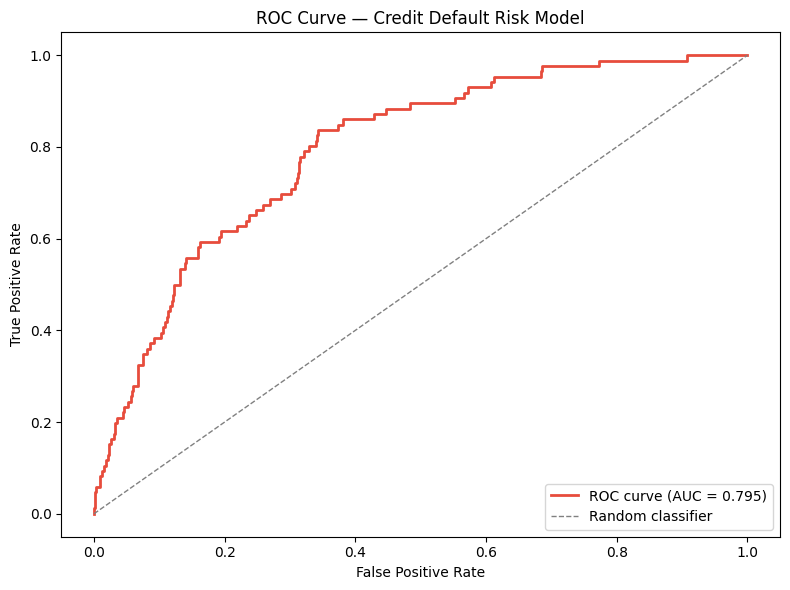

ROC curve saved to ../data/roc_curve.png


In [20]:
# Full evaluation on test set
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
import matplotlib.pyplot as plt

# Score all test samples in batches of 100
all_scores = []
batch_size = 100

for i in range(0, min(1000, len(X_test)), batch_size):  # use 1000 rows to save cost
    batch = X_test.iloc[i:i+batch_size]
    batch_csv = batch.to_csv(header=False, index=False)
    resp = sm_runtime.invoke_endpoint(
        EndpointName=ENDPOINT_NAME,
        ContentType="text/csv",
        Body=batch_csv
    )
    batch_scores = [float(s) for s in resp["Body"].read().decode().strip().split("\n")]
    all_scores.extend(batch_scores)

y_subset  = y_test.iloc[:len(all_scores)]
auc_score = roc_auc_score(y_subset, all_scores)
print(f"Live endpoint AUC-ROC (1000 samples): {auc_score:.4f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_subset, all_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="#e74c3c", lw=2, label=f"ROC curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Credit Default Risk Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../data/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("ROC curve saved to ../data/roc_curve.png")

### 4. Create Lambda function for REST API

In [21]:
import zipfile
import os

# Write Lambda function code
lambda_code = f'''
import boto3
import json
import os

ENDPOINT_NAME = "{ENDPOINT_NAME}"
sm_runtime = boto3.client("sagemaker-runtime")

def lambda_handler(event, context):
    try:
        body = json.loads(event.get("body", "{{}}"))
        features = body.get("features", [])

        if not features:
            return {{
                "statusCode": 400,
                "body": json.dumps({{"error": "features list is required"}})
            }}

        payload = ",".join(str(v) for v in features)

        response = sm_runtime.invoke_endpoint(
            EndpointName=ENDPOINT_NAME,
            ContentType="text/csv",
            Body=payload
        )

        score = float(response["Body"].read().decode().strip())
        risk  = "HIGH" if score >= 0.5 else "LOW"

        return {{
            "statusCode": 200,
            "headers": {{"Content-Type": "application/json"}},
            "body": json.dumps({{
                "default_probability": round(score, 4),
                "risk_label":          risk,
                "threshold":           0.5,
                "model_endpoint":      ENDPOINT_NAME
            }})
        }}

    except Exception as e:
        return {{
            "statusCode": 500,
            "body": json.dumps({{"error": str(e)}})
        }}
'''

os.makedirs("../lambda", exist_ok=True)
with open("../lambda/lambda_function.py", "w") as f:
    f.write(lambda_code)

# Create deployment zip
with zipfile.ZipFile("../lambda/lambda_function.zip", "w") as zf:
    zf.write("../lambda/lambda_function.py", "lambda_function.py")

print("Lambda function code written to ../lambda/lambda_function.py")

Lambda function code written to ../lambda/lambda_function.py


In [ ]:
# Deploy Lambda function
lambda_client = boto_session.client("lambda")
iam_client    = boto_session.client("iam")

LAMBDA_NAME  = "credit-risk-scorer"
LAMBDA_ROLE  = ROLE   

with open("../lambda/lambda_function.zip", "rb") as f:
    zip_bytes = f.read()

try:
    response = lambda_client.create_function(
        FunctionName=LAMBDA_NAME,
        Runtime="python3.11",
        Role=LAMBDA_ROLE,
        Handler="lambda_function.lambda_handler",
        Code={"ZipFile": zip_bytes},
        Description="Credit risk scoring via SageMaker endpoint",
        Timeout=30,
        MemorySize=256
    )
    lambda_arn = response["FunctionArn"]
    print(f"Lambda created: {lambda_arn}")

except lambda_client.exceptions.ResourceConflictException:
    # Function already exists — update the code
    response = lambda_client.update_function_code(
        FunctionName=LAMBDA_NAME,
        ZipFile=zip_bytes
    )
    lambda_arn = response["FunctionArn"]
    print(f"Lambda updated: {lambda_arn}")

Lambda created: arn:aws:lambda:us-east-1:064990711629:function:credit-risk-scorer


In [25]:
# Create HTTP API Gateway
apigw = boto_session.client("apigatewayv2")

api = apigw.create_api(
    Name="credit-risk-api",
    ProtocolType="HTTP",
    Description="Credit default risk scoring API"
)
api_id  = api["ApiId"]
api_url = f"https://{api_id}.execute-api.{REGION}.amazonaws.com"

# Create Lambda integration
integration = apigw.create_integration(
    ApiId=api_id,
    IntegrationType="AWS_PROXY",
    IntegrationUri=lambda_arn,
    PayloadFormatVersion="2.0"
)

# Create POST /predict route
apigw.create_route(
    ApiId=api_id,
    RouteKey="POST /predict",
    Target=f"integrations/{integration['IntegrationId']}"
)

# Deploy
apigw.create_stage(
    ApiId=api_id,
    StageName="$default",
    AutoDeploy=True
)

# Allow API Gateway to invoke Lambda
lambda_client.add_permission(
    FunctionName=LAMBDA_NAME,
    StatementId="api-gateway-invoke",
    Action="lambda:InvokeFunction",
    Principal="apigateway.amazonaws.com",
    SourceArn=f"arn:aws:execute-api:{REGION}:{boto_session.client('sts').get_caller_identity()['Account']}:{api_id}/*/*/predict"
)

predict_url = f"{api_url}/predict"
print(f"\nREST API deployed!")
print(f"Endpoint URL: {predict_url}")
print(f"\nTest with:")
print(f'curl -X POST {predict_url} -H "Content-Type: application/json" -d \'{{"features": [<comma-separated feature values>]}}\'\n')


REST API deployed!
Endpoint URL: https://z0zxndcizk.execute-api.us-east-1.amazonaws.com/predict

Test with:
curl -X POST https://z0zxndcizk.execute-api.us-east-1.amazonaws.com/predict -H "Content-Type: application/json" -d '{"features": [<comma-separated feature values>]}'



In [26]:
# Test the live REST API
import urllib.request

sample_features = X_test.iloc[0].tolist()
payload = json.dumps({"features": sample_features}).encode()

req = urllib.request.Request(
    predict_url,
    data=payload,
    headers={"Content-Type": "application/json"},
    method="POST"
)

with urllib.request.urlopen(req) as resp:
    result = json.loads(resp.read().decode())

print("Live API response:")
print(json.dumps(result, indent=2))
print(f"\nActual label: {int(y_test.iloc[0])}")

Live API response:
{
  "default_probability": 0.3,
  "risk_label": "LOW",
  "threshold": 0.5,
  "model_endpoint": "credit-risk-realtime"
}

Actual label: 0


In [27]:
# Save API URL to config
with open("../data/config.json") as f:
    cfg = json.load(f)

cfg["ENDPOINT_NAME"] = ENDPOINT_NAME
cfg["LAMBDA_ARN"]    = lambda_arn
cfg["API_URL"]       = predict_url
cfg["API_ID"]        = api_id

with open("../data/config.json", "w") as f:
    json.dump(cfg, f, indent=2)

print(f"Config updated.")
print(f"API URL saved: {predict_url}")

Config updated.
API URL saved: https://z0zxndcizk.execute-api.us-east-1.amazonaws.com/predict


In [ ]:
# ⚠️  RUN THIS WHEN YOU'RE DONE DEMOING

sm_client.delete_endpoint(EndpointName=ENDPOINT_NAME)
sm_client.delete_endpoint_config(EndpointConfigName=CONFIG_NAME)

print("The Endpoint is deleted.")


The Endpoint is deleted.
